In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from src.main import add_polynomial_features, MyPloter as MyPlt, MyLinearRegression as MyLR
from src.fit import fit_
from src.gradient import gradient
from src.loss import loss_
from src.prediction import simple_predict, predict_
from src.standardization import zscore


In [ ]:
x = np.arange(1,13).reshape((4,-1))

theta1 = np.array([5, 0, 0, 0]).reshape((-1, 1))
assert np.allclose(simple_predict(x, theta1), np.array([[5.], [5.], [5.], [5.]]))

theta2 = np.array([0, 1, 0, 0]).reshape((-1, 1))
assert np.allclose(simple_predict(x, theta2), np.array([[ 1.], [ 4.], [ 7.], [10.]]))

theta3 = np.array([-1.5, 0.6, 2.3, 1.98]).reshape((-1, 1))
assert np.allclose(simple_predict(x, theta3), np.array([[ 9.64], [24.28], [38.92], [53.56]]))

theta4 = np.array([-3, 1, 2, 3.5]).reshape((-1, 1))
assert np.allclose(simple_predict(x, theta4), np.array([[12.5], [32. ], [51.5], [71. ]]))

In [ ]:
x = np.arange(1,13).reshape((4,-1))

theta1 = np.array([5, 0, 0, 0]).reshape((-1, 1))
assert np.allclose(predict_(x, theta1), np.array([[5.], [5.], [5.], [5.]]))

theta2 = np.array([0, 1, 0, 0]).reshape((-1, 1))
assert np.allclose(predict_(x, theta2), np.array([[ 1.], [ 4.], [ 7.], [10.]]))

theta3 = np.array([-1.5, 0.6, 2.3, 1.98]).reshape((-1, 1))
assert np.allclose(predict_(x, theta3), np.array([[ 9.64], [24.28], [38.92], [53.56]]))

theta4 = np.array([-3, 1, 2, 3.5]).reshape((-1, 1))
assert np.allclose(predict_(x, theta4), np.array([[12.5], [32. ], [51.5], [71. ]]))

In [ ]:
X = np.array([0, 15, -9, 7, 12, 3, -21]).reshape((-1, 1))
Y = np.array([2, 14, -13, 5, 12, 4, -19]).reshape((-1, 1))
assert loss_(X, Y) == 2.142857142857143
assert loss_(X, X) == 0.0


In [ ]:
x = np.array([
[ -6, -7, -9],
[ 13, -2, 14],
[ -7, 14, -1],
[ -8, -4, 6],
[ -5, -9, 6],
[ 1, -5, 11],
[ 9, -11, 8]])
y = np.array([2, 14, -13, 5, 12, 4, -19]).reshape((-1, 1))
theta1 = np.array([0, 3, 0.5, -6]).reshape((-1, 1))

# print(f"{gradient(x, y, theta1)=}")
# print(f"{x.shape=}, {y.shape=}, {theta1.shape=}")

assert np.allclose(gradient(x, y, theta1), np.array([[-33.71428571], [-37.35714286], [183.14285714], [-393.0]]))
theta2 = np.array([0, 0, 0, 0]).reshape((-1, 1))

assert np.allclose(gradient(x, y, theta2), np.array([[-0.71428571], [0.85714286], [23.28571429], [-26.42857143]]))

x = np.array([[0.2, 2., 20.], [0.4, 4., 40.], [0.6, 6., 60.], [0.8, 8., 80.]])
y = np.array([[19.6], [-2.8], [-25.2], [-47.6]])
theta = np.array([[42.], [1.], [1.], [1.]])
theta2 = fit_(x, y, theta, alpha = 0.0005, max_iter=42000)
assert np.allclose(theta2, np.array([[41.9999], [0.9714], [0.7714], [-1.2000]]), rtol=1e-1)

assert np.allclose(predict_(x, theta2), np.array([[19.5992], [-2.8003], [-25.1999], [-47.5996]]), rtol=1e-2)


In [ ]:
X = np.array([[1., 1., 2., 3.], [5., 8., 13., 21.], [34., 55., 89., 144.]])
Y = np.array([[23.], [48.], [218.]])
mylr = MyLR([[1.], [1.], [1.], [1.], [1]])

y_hat = mylr.predict_(X)
assert np.allclose(y_hat, np.array([[8.], [48.], [323.]]))
assert np.allclose(mylr.loss_elem_(Y, y_hat), np.array([[225.], [0.], [11025.]]))
assert np.allclose(mylr.loss_(Y, y_hat), 1875.0)

mylr.alpha = 1.6e-4
mylr.max_iter = 200000
mylr.thetas = np.ones((X.shape[1] + 1, 1))
mylr.fit_(X, Y)
# print(f"{mylr.thetas=}")
assert np.allclose(mylr.thetas, np.array([[18.188], [2.767], [-0.374], [1.392], [0.017]]), rtol=1e-1)

y_hat = mylr.predict_(X)
# print(f"{y_hat=}")
assert np.allclose(y_hat, np.array([[23.417], [47.489], [218.065]]), rtol=1e-2)
assert np.allclose(mylr.loss_elem_(Y, y_hat), np.array([[0.174], [0.260], [0.004]]), rtol=1e-1)
assert np.allclose(mylr.loss_(Y, y_hat), 0.0732, rtol=1e-2)

In [ ]:
df = pd.read_csv("../attachments/spacecraft_data.csv")
Age = np.array(df[["Age"]])
Sell_price = np.array(df[["Sell_price"]])
Thrust_power = np.array(df[["Thrust_power"]])
Terameters = np.array(df[["Terameters"]])

In [ ]:
figures = 3
plotter = MyPlt((1, figures))
plotter.scatter(Age, Sell_price, xlabel=f"$x_{{\\text{{1}}}}$: age (in years)", ylabel="y: sell price (in keuros)", label="Sell price")
plotter.scatter(Thrust_power, Sell_price, xlabel=f"$x_{{\\text{{2}}}}$: thrust power(in 10Km/s)", ylabel="y: sell price (in keuros)", label="Sell price", color="green", ax_id=1)
plotter.scatter(Terameters, Sell_price, xlabel=f"$x_{{\\text{{3}}}}$: distance totalizer value of spacecraft (in Tmeters)", ylabel="y: sell price (in keuros)", label="Sell price", color="darkviolet", ax_id=2)


myLR_age = MyLR([[1000.0], [-1.0]], alpha=5e-5, max_iter=500000)
myLR_age.fit_(Age, Sell_price)
y_hat = myLR_age.predict_(Age)

myLR_thrust = MyLR([[1.0], [-1.0]], alpha=5e-5, max_iter=500000)
myLR_thrust.fit_(Thrust_power, Sell_price)
y_hat2 = myLR_thrust.predict_(Thrust_power)

myLR_tm = MyLR([[1.0], [-1.0]], alpha=5e-5, max_iter=500000)
myLR_tm.fit_(Terameters, Sell_price)
y_hat3 = myLR_tm.predict_(Terameters)

plotter.plot(Age, y_hat, param_dict={
    'color':'cyan',
    'linestyle':'dotted',
    'label':'Predicted sell price'
})

plotter.plot(Thrust_power, y_hat2,param_dict={
    'color':'lime',
    'linestyle':'dotted',
    'label':'Predicted sell price'
}, ax_id=1)
plotter.plot(Terameters, y_hat3, param_dict={
    'color':'violet',
    'linestyle':'dotted',
    'label':'Predicted sell price'
}, ax_id=2)
print(myLR_age.mse_(Sell_price, y_hat))
print(myLR_thrust.mse_(Sell_price, y_hat2))
print(myLR_tm.mse_(Sell_price, y_hat3))


In [ ]:
X = np.array(df[["Age", "Thrust_power", "Terameters"]])
Y = np.array(df[["Sell_price"]])

my_lreg = MyLR(thetas=[1.0, 1.0, 1.0, 1.0], alpha=9e-5, max_iter=500000)

y_hat = my_lreg.predict_(X)

assert np.allclose(my_lreg.mse_(Y, y_hat), 144044.877, rtol=1e-2)
my_lreg.fit_(X, Y)
my_lreg.plot_learning_curve()

assert np.allclose(my_lreg.thetas, np.array([[367.288], [-23.699], [5.736], [-2.638]]), rtol=1e-2)

y_hat2 = my_lreg.predict_(X)
assert np.allclose(my_lreg.mse_(Y, y_hat2), 435.9325695, rtol=1e-2)


In [ ]:
figures = 3
plotter = MyPlt((1, figures), (15, 5))
plotter.scatter(Age, Y, xlabel=f"$x_{{\\text{{1}}}}$: age (in years)", ylabel="y: sell price (in keuros)", label="Sell price")
plotter.scatter(Thrust_power, Y, xlabel=f"$x_{{\\text{{2}}}}$: thrust power(in 10Km/s)", ylabel="y: sell price (in keuros)", label="Sell price", color="green", ax_id=1)
plotter.scatter(Terameters, Y, xlabel=f"$x_{{\\text{{3}}}}$: distance totalizer value of spacecraft (in Tmeters)", ylabel="y: sell price (in keuros)", label="Sell price", color="darkviolet", ax_id=2)

plotter.scatter(Age, y_hat2, xlabel=f"$x_{{\\text{{1}}}}$: age (in years)", ylabel="y: sell price (in keuros)", label="Sell price", color="deepskyblue", s=5)
plotter.scatter(Thrust_power, y_hat2, xlabel=f"$x_{{\\text{{2}}}}$: thrust power(in 10Km/s)", ylabel="y: sell price (in keuros)", label="Sell price", color="lime", s=5, ax_id=1)
plotter.scatter(Terameters, y_hat2, xlabel=f"$x_{{\\text{{3}}}}$: distance totalizer value of spacecraft (in Tmeters)", ylabel="y: sell price (in keuros)", label="Sell price", color="violet", s=5, ax_id=2)


In [ ]:
x = np.arange(1,6).reshape(-1, 1)

print(add_polynomial_features(x, 3))
print(sklearn.preprocessing.PolynomialFeatures(degree=3, include_bias=False).fit_transform(x).astype(int))
assert np.array_equal(add_polynomial_features(x, 6), np.array([[1, 1, 1, 1, 1, 1],
                                                               [2, 4, 8, 16, 32, 64],
                                                               [3, 9, 27, 81, 243, 729],
                                                               [4, 16, 64, 256, 1024, 4096],
                                                               [5, 25, 125, 625, 3125, 15625]]))
assert np.array_equal(sklearn.preprocessing.PolynomialFeatures(degree=6, include_bias=False).fit_transform(x).astype(int), np.array([[1, 1, 1, 1, 1, 1], [2, 4, 8, 16, 32, 64], [3, 9, 27, 81, 243, 729], [4, 16, 64, 256, 1024, 4096], [5, 25, 125, 625, 3125, 15625]]))

print(add_polynomial_features(x, 6))
print(sklearn.preprocessing.PolynomialFeatures(degree=6, include_bias=False).fit_transform(x).astype(int))
assert np.array_equal(add_polynomial_features(x, 6), np.array([[1, 1, 1, 1, 1, 1],
                                                               [2, 4, 8, 16, 32, 64],
                                                               [3, 9, 27, 81, 243, 729],
                                                               [4, 16, 64, 256, 1024, 4096],
                                                               [5, 25, 125, 625, 3125, 15625]]))
assert np.array_equal(sklearn.preprocessing.PolynomialFeatures(degree=6, include_bias=False).fit_transform(x).astype(int), np.array([[1, 1, 1, 1, 1, 1], [2, 4, 8, 16, 32, 64], [3, 9, 27, 81, 243, 729], [4, 16, 64, 256, 1024, 4096], [5, 25, 125, 625, 3125, 15625]]))



In [ ]:
x = np.arange(1,11).reshape(-1,1)
y = np.array([[ 1.39270298],
[ 3.88237651],
[ 4.37726357],
[ 4.63389049],
[ 7.79814439],
[ 6.41717461],
[ 8.63429886],
[ 8.19939795],
[10.37567392],
[10.68238222]])

x_ = add_polynomial_features(x, 3)
x_norm = zscore(x_)
my_lr = MyLR(np.ones(4).reshape(-1,1), alpha=1e-1, max_iter=15000).fit_(x_norm, y)
my_lr.plot_learning_curve()
# Plot:
## To get a smooth curve, we need a lot of data points
continuous_x = np.arange(1,10.01, 0.01).reshape(-1,1)
x_plot = add_polynomial_features(continuous_x, 3)
x_plot_norm = zscore(x_plot)
y_hat = my_lr.predict_(x_plot_norm)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(x,y)
axs[1].scatter(x,y)
axs[1].plot(continuous_x, y_hat, color='orange')


In [ ]:
df = pd.read_csv("../attachments/are_blue_pills_magics.csv")
x = np.array(df[["Micrograms"]])
y = np.array(df[["Score"]])

theta1 = np.array([[1.0, 1.0]])
theta2 = np.array([[1.0, 1.0, 1.0]])
theta3 = np.array([[1.0, 1.0, 1.0, 1.0]])
theta4 = np.array([[-20],[ 160],[ -80],[ 10],[ -1]]).reshape(-1,1)
theta5 = np.array([[1140],[ -1850],[ 1110],[ -305],[ 40],[ -2]]).reshape(-1,1)
theta6 = np.array([[9110],[ -18015],[ 13400],[ -4935],[ 966],[ -96.4],[ 3.86]]).reshape(-1,1)

x2 = add_polynomial_features(x, 2)
x3 = add_polynomial_features(x, 3)
x4 = add_polynomial_features(x, 4)
x5 = add_polynomial_features(x, 5)
x6 = add_polynomial_features(x, 6)

x_norm = zscore(x)
x2_norm = zscore(x2)
x3_norm = zscore(x3)
x4_norm = zscore(x4)
x5_norm = zscore(x5)
x6_norm = zscore(x6)

lr1 = MyLR(theta1, alpha=5.5e-4, max_iter=50000).fit_(x_norm, y)
lr2 = MyLR(theta2, alpha=5.5e-4, max_iter=50000).fit_(x2_norm, y)
lr3 = MyLR(theta3, alpha=5.5e-4, max_iter=50000).fit_(x3_norm, y)
lr4 = MyLR(theta4, alpha=5.5e-4, max_iter=50000).fit_(x4_norm, y)
lr5 = MyLR(theta5, alpha=5.5e-4, max_iter=50000).fit_(x5_norm, y)
lr6 = MyLR(theta6, alpha=5.5e-4, max_iter=50000).fit_(x6_norm, y)

y_hat = lr1.predict_(x_norm)
y_hat2 = lr2.predict_(x2_norm)
y_hat3 = lr3.predict_(x3_norm)
y_hat4 = lr4.predict_(x4_norm)
y_hat5 = lr5.predict_(x5_norm)
y_hat6 = lr6.predict_(x6_norm)

mse = lr1.mse_(y, y_hat)
mse2 = lr2.mse_(y, y_hat2)
mse3 = lr3.mse_(y, y_hat3)
mse4 = lr4.mse_(y, y_hat4)
mse5 = lr5.mse_(y, y_hat5)
mse6 = lr6.mse_(y, y_hat6)

print(f"{mse=}")
print(f"{mse2=}")
print(f"{mse3=}")
print(f"{mse4=}")
print(f"{mse5=}")
print(f"{mse6=}")

poly_degrees = np.arange(1, 7, 1)
mse_scores = np.array([mse, mse2, mse3, mse4, mse5, mse6])
mse_scores_norm = zscore(mse_scores)
bar_labels = ['deg=1', 'deg=2', 'deg=3', 'deg=4', 'deg=5', 'deg=6']
bar_colors = ['lime', 'green', 'limegreen', 'orange', 'orangered', 'red']
fig, ax = plt.subplots()
ax.bar(poly_degrees, mse_scores, label=bar_labels, color=bar_colors)
ax.set_yscale("log")
ax.set_ylabel('mse')

plt.legend()
plt.show()

# lr1.plot_learning_curve()
# lr2.plot_learning_curve()
# lr3.plot_learning_curve()
# lr4.plot_learning_curve()
# lr5.plot_learning_curve()
# lr6.plot_learning_curve()

continuous_x = np.arange(1, 7.01, 0.01).reshape(-1,1)
x_plot = continuous_x
x_plot_2 = add_polynomial_features(continuous_x, 2)
x_plot_3 = add_polynomial_features(continuous_x, 3)
x_plot_4 = add_polynomial_features(continuous_x, 4)
x_plot_5 = add_polynomial_features(continuous_x, 5)
x_plot_6 = add_polynomial_features(continuous_x, 6)

x_plotnorm = zscore(x_plot)
x2_plotnorm = zscore(x_plot_2)
x3_plotnorm = zscore(x_plot_3)
x4_plotnorm = zscore(x_plot_4)
x5_plotnorm = zscore(x_plot_5)
x6_plotnorm = zscore(x_plot_6)

y_hat = lr1.predict_(x_plotnorm)
y_hat2 = lr2.predict_(x2_plotnorm)
y_hat3 = lr3.predict_(x3_plotnorm)
y_hat4 = lr4.predict_(x4_plotnorm)
y_hat5 = lr5.predict_(x5_plotnorm)
y_hat6 = lr6.predict_(x6_plotnorm)

plotter = MyPlt((1, 6), (20, 10))
plotter.scatter(x, y, xlabel='Micrograms', ylabel='Score')
plotter.scatter(x, y, xlabel='Micrograms', ylabel='Score', ax_id=1)
plotter.scatter(x, y, xlabel='Micrograms', ylabel='Score', ax_id=2)
plotter.scatter(x, y, xlabel='Micrograms', ylabel='Score', ax_id=3)
plotter.scatter(x, y, xlabel='Micrograms', ylabel='Score', ax_id=4)
plotter.scatter(x, y, xlabel='Micrograms', ylabel='Score', ax_id=5)

plotter.plot(continuous_x, y_hat, param_dict={
    'color':'cyan',
    'linestyle':'dotted',
    'label':'Predicted sell price'
})
plotter.plot(continuous_x, y_hat2, param_dict={
    'color':'coral',
    'linestyle':'dotted',
    'label':'Predicted sell price'
}, ax_id=1)
plotter.plot(continuous_x, y_hat3, param_dict={
    'color':'dodgerblue',
    'linestyle':'dotted',
    'label':'Predicted sell price'
}, ax_id=2)
plotter.plot(continuous_x, y_hat4, param_dict={
    'color':'navy',
    'linestyle':'dotted',
    'label':'Predicted sell price'
}, ax_id=3)
plotter.plot(continuous_x, y_hat5, param_dict={
    'color':'green',
    'linestyle':'dotted',
    'label':'Predicted sell price'
}, ax_id=4)

plotter.plot(continuous_x, y_hat6, param_dict={
    'color':'violet',
    'linestyle':'dotted',
    'label':'Predicted sell price'
}, ax_id=5)



In [2]:
from src.data_spliter import data_spliter


df = pd.read_csv("../attachments/space_avocado.csv")
print(df.describe())

X = zscore(np.array(df[['weight', 'prod_distance', 'time_delivery']]))
Y = zscore(np.array(df[["target"]]))


(x_train, x_test, y_train, y_test) = data_spliter(X, Y, .75)
print(f"{x_train.shape=} {y_train.shape=} {x_test.shape=} {y_test.shape=}")

            index      weight  prod_distance  time_delivery         target
count  4900.00000  4900.00000    4900.000000     4900.00000    4900.000000
mean   2449.50000    41.50000    2040.228571        7.50000  644119.132497
std    1414.65249    25.85317     497.144577        4.03154   96580.273849
min       0.00000     1.00000    1161.000000        1.00000  447037.914001
25%    1224.75000    19.00000    1731.000000        4.00000  565950.283350
50%    2449.50000    41.50000    2074.000000        7.50000  650534.690676
75%    3674.25000    64.00000    2476.000000       11.00000  724377.866264
max    4899.00000    82.00000    2936.000000       14.00000  844204.970857
x_train.shape=(3675, 3) y_train.shape=(3675, 1) x_test.shape=(1225, 3) y_test.shape=(1225, 1)


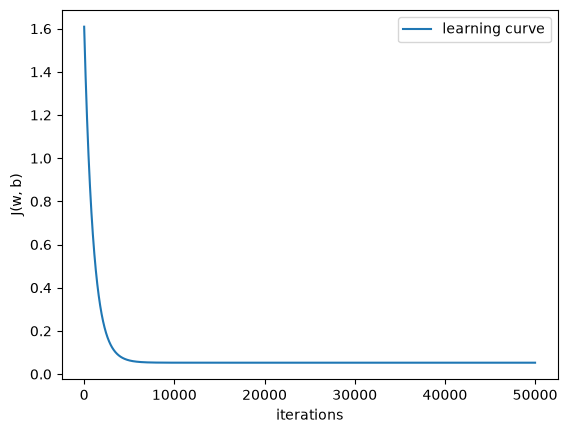

x.shape=(1225, 3675) y.shape=(1225, 3675)


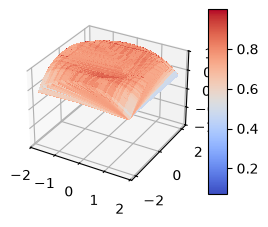

In [3]:
theta1 = np.ones(4).reshape(-1,1)
theta2 = np.ones(5).reshape(-1,1)
theta3 = np.ones(6).reshape(-1,1)
theta4 = np.ones(7).reshape(-1,1)

space1 = MyLR(theta1, alpha=5e-4, max_iter=50000).fit_(x_train, y_train)
space1.plot_learning_curve()
y_hat = space1.predict_(x_test)

fig = plt.figure()
ax = fig.add_subplot(1, 2, 1, projection='3d')

x, y = np.meshgrid(x_test, y_test)
print(f"{x.shape=} {y.shape=}")
r = np.sqrt(x**2 + y**2)
z = np.sin(r)

surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap="coolwarm", linewidth=0, antialiased=False)
ax.set_zlim(-1.01, 1.01)
fig.colorbar(surf, shrink=0.5, aspect=10)

# ax.set_xlabel('weight')
# ax.set_ylabel('prediction')
# ax.set_zlabel('prod_distance')
plt.show()


# print(x_train.shape)

# x_train2 = add_polynomial_features(x_train, 2)
# print(x_train2)
# space2 = MyLR(theta2, alpha=5e-4, max_iter=50000).fit_(x_train2, y_train)

# x_train3 = add_polynomial_features(x_train, 3)
# space3 = MyLR(theta3, alpha=5e-4, max_iter=50000).fit_(x_train3, y_train)

# x_train4 = add_polynomial_features(x_train, 4)
# space4 = MyLR(theta4, alpha=5e-4, max_iter=50000).fit_(x_train4, y_train)

